  IC3392: 14884 HII pixels
  NGC4064: 6820 HII pixels
  NGC4064: 6820 HII pixels
  NGC4192: 145934 HII pixels
  NGC4293: 3854 HII pixels
  NGC4192: 145934 HII pixels
  NGC4293: 3854 HII pixels
  NGC4298: 156350 HII pixels
  NGC4298: 156350 HII pixels
  NGC4330: 42566 HII pixels
  NGC4383: 75127 HII pixels
  NGC4330: 42566 HII pixels
  NGC4383: 75127 HII pixels
  NGC4396: 81728 HII pixels
  NGC4419: 6886 HII pixels
  NGC4396: 81728 HII pixels
  NGC4419: 6886 HII pixels
  NGC4457: 6000 HII pixels
  NGC4457: 6000 HII pixels
  NGC4501: 260854 HII pixels
  NGC4522: 39354 HII pixels
  NGC4501: 260854 HII pixels
  NGC4522: 39354 HII pixels
  NGC4694: 2585 HII pixels
  NGC4694: 2585 HII pixels
  NGC4698: 10042 HII pixels

Total combined HII pixels: 852984
  NGC4698: 10042 HII pixels

Total combined HII pixels: 852984

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 852984 (100.0%)
  S2 BPT - Total HII: 852984 (100.0%)

Galaxy breakdown for HII spaxels:
  IC3392: N2_HII=14

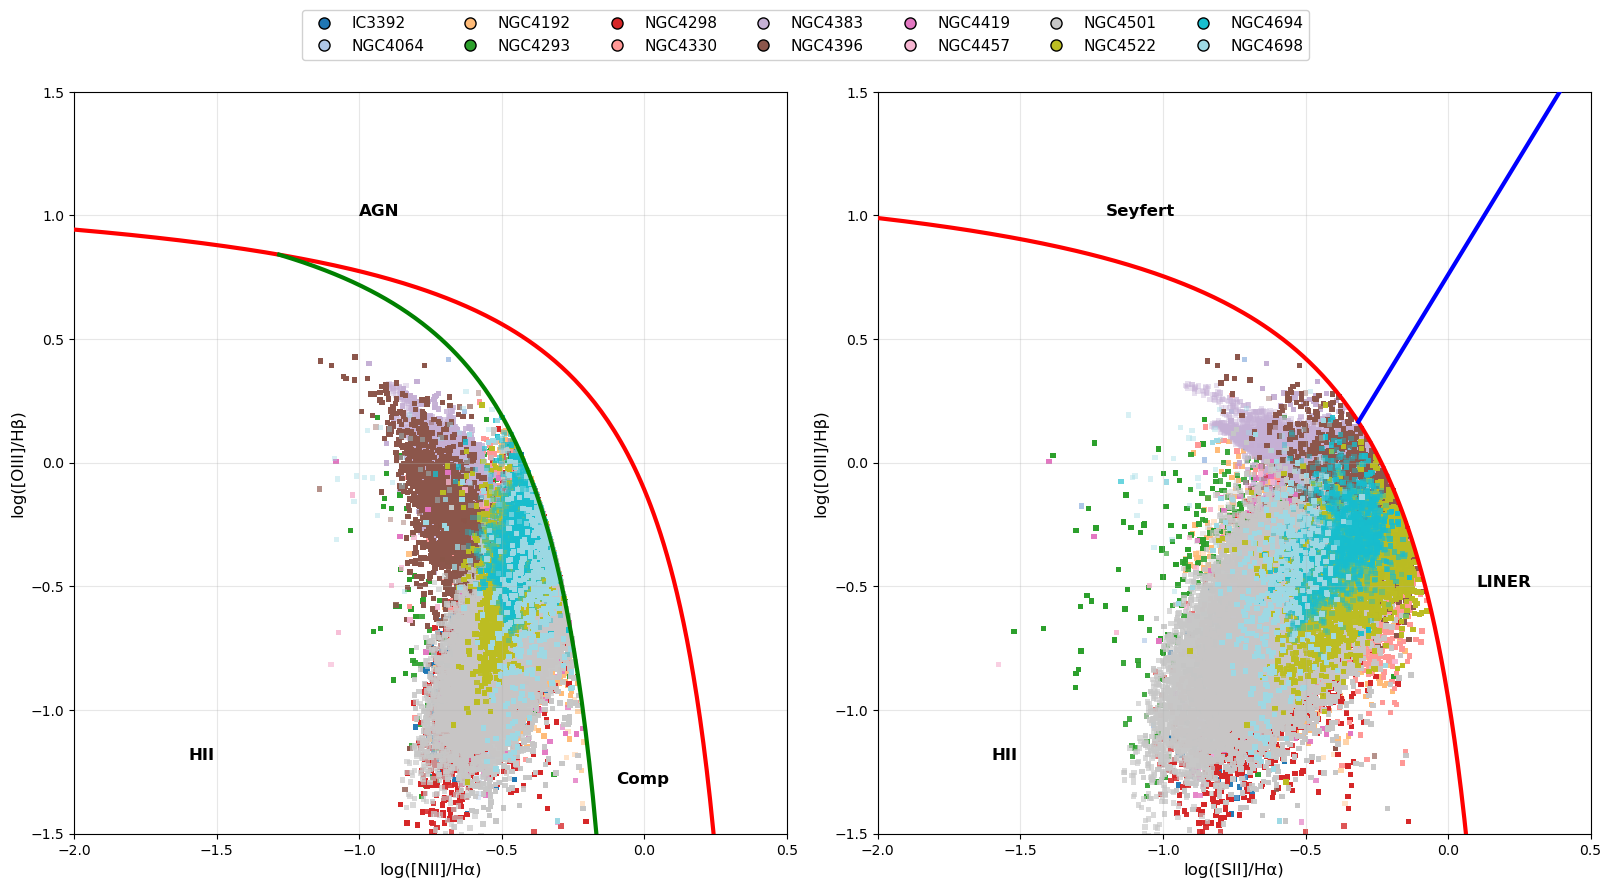

In [1]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy
# Collect all HII spaxels from all galaxies (HII only, no SF)
# Uses common spaxels across all 4 metallicity calibrations
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Create galaxy color mapping (consistent for all HII regions)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))

# Collect all spaxels from all galaxies - HII only (with galaxy indices)
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_galaxy_indices_hii = []

print("Collecting HII data from all galaxies...")
for gal_idx, gal in enumerate(galaxies):
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII quantities
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data

            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data

        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                           np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))

        n_pixels_HII = np.sum(common_mask_HII)
        print(f"  {gal}: {n_pixels_HII} HII pixels")

        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]
        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]

        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)

        # Append to combined arrays - HII only
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)

print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")

# Apply BPT classifications - HII only
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)
mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))
mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))

mask_HII_N2 = mask_N2_HII | mask_N2_Comp
mask_HII_S2 = mask_S2_HII

# Create BPT diagrams: HII only (single row, two panels)
# Use constrained_layout for better spacing with legend
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# ===== HII REGIONS ONLY =====

# NII BPT Diagram - HII
ax = axes[0]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_N2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - HII
ax = axes[1]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_S2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)

hii_count_S2 = np.sum(mask_HII_S2)
hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Build custom legend handles with larger markers
legend_handles = []
legend_labels = []
for gal_idx, gal in enumerate(galaxies):
    legend_handles.append(Line2D([0], [0], marker='o', color='none', 
                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))
    legend_labels.append(f'{gal}')

# Put legend above the axes at 1.1 (outside plot)
fig.legend(legend_handles, legend_labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(legend_labels), 7), fontsize=11, framealpha=0.9)

# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)
fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

# Print summary statistics (HII only)
print(f"\n=== Combined BPT Diagram Summary (HII only) ===")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")

# Print galaxy breakdown for HII spaxels
print(f"\nGalaxy breakdown for HII spaxels:")
for gal_idx, gal in enumerate(galaxies):
    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)
    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)
    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")

print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")

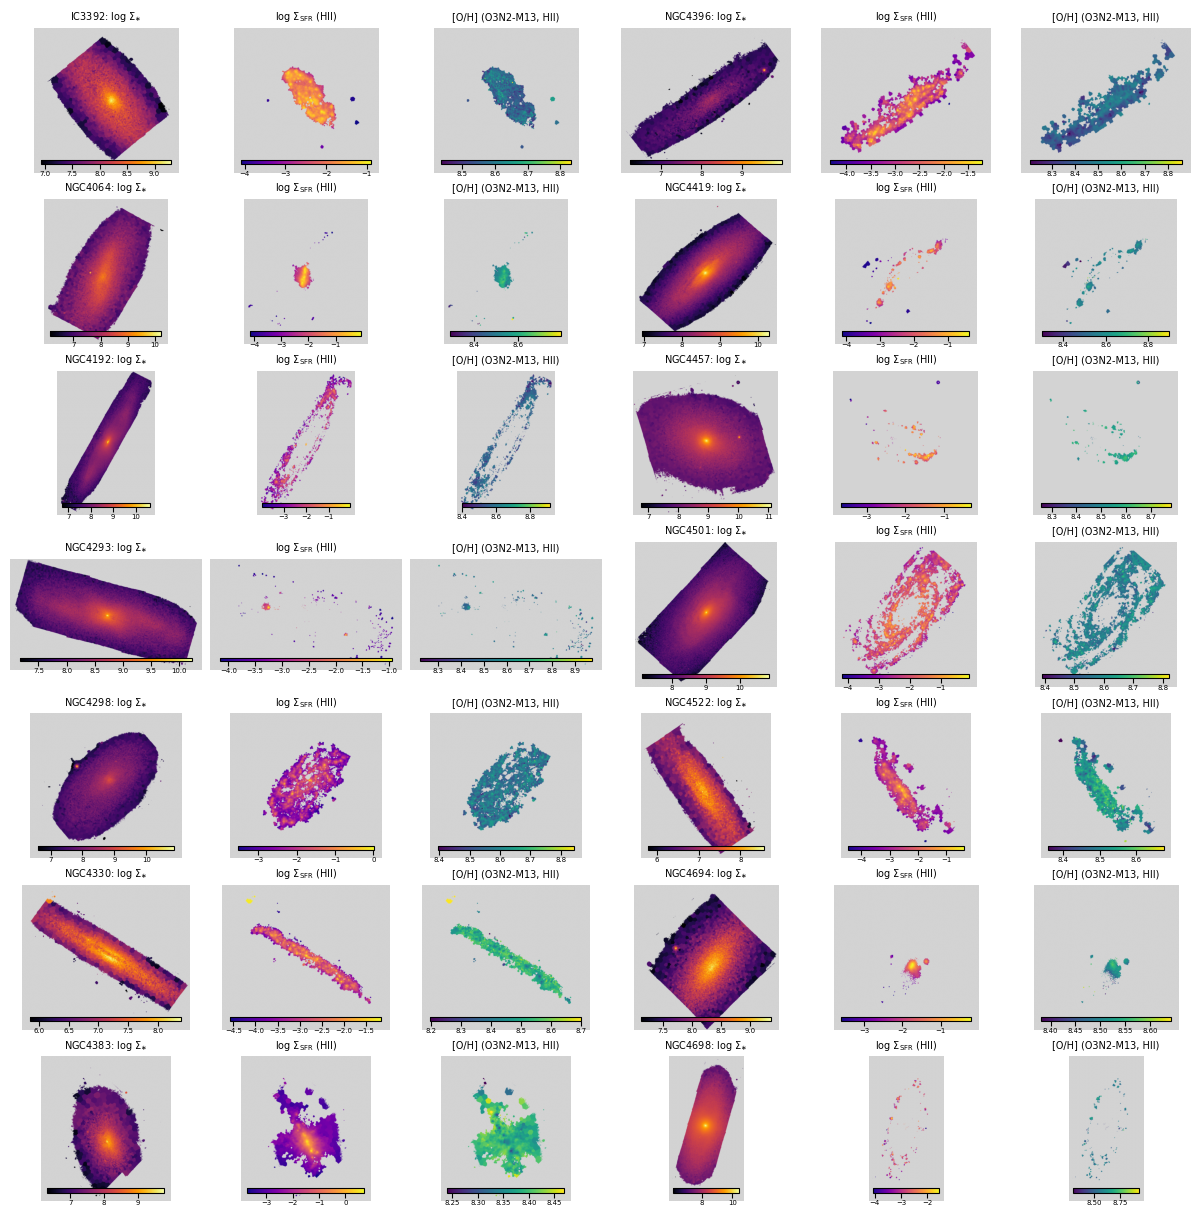

In [2]:
# --------------------------------------------------------------
# Maps: Σ_M*, Σ_SFR and [O/H] (O3N2-M13) maps for each galaxy
# Using HII spaxels (common HII for Σ_SFR and O/H only)
# Layout: up to 14 galaxies in 7 rows × 6 columns
# Columns per row: [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from astropy.io import fits

# 0 · discover galaxies
gas_bins = sorted(Path('.').glob('*_gas_BIN_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in gas_bins]          # 14 expected
ngal     = len(galaxies)
assert ngal <= 14, "This layout assumes ≤ 14 galaxies."

# 1 · helpers to load maps (no mask for mass; HII mask for Σ_SFR and O/H)
def load_maps_hii(gal):
    """
    Load stellar-mass surface density (from spatial-binning file),
    Σ_SFR (HII), and [O/H] (O3N2-M13, HII) for a galaxy.

    - Σ_M* is shown wherever it is finite (no HII mask).
    - Σ_SFR and [O/H] use a common HII mask requiring both to be finite.
    """
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        sigSFR_HII     = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2m13_HII = h_gas['O_H_O3N2_M13_HII'].data

    # Mass: just require Σ_M* to be finite
    mass_mask   = np.isfinite(logSigmaM)
    logSigmaM_c = np.where(mass_mask, logSigmaM, np.nan)

    # HII common mask for Σ_SFR and O/H
    hii_mask        = (np.isfinite(sigSFR_HII) & np.isfinite(oh_o3n2m13_HII))
    sigSFR_HII_c    = np.where(hii_mask, sigSFR_HII, np.nan)
    oh_o3n2m13_c    = np.where(hii_mask, oh_o3n2m13_HII, np.nan)

    return logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c

# 2 · figure & GridSpec  (rows=7, cols=6 → two 3-column blocks per row)
# Use constrained_layout for better handling of colorbars and spacing
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs  = GridSpec(
        nrows=7, ncols=6, figure=fig,
        width_ratios=[1, 1, 1, 1, 1, 1],      # [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
        wspace=0.00, hspace=0.00
)

for idx, gal in enumerate(galaxies):
    row  = idx % 7                      # 0–6
    blk  = idx // 7                     # 0 or 1   (left / right 3-column block)
    col0 = blk * 3                      # 0 or 3   (start col of that block)

    logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii(gal)

    # Σ_M* map with NaN shown as light gray
    axM = fig.add_subplot(gs[row, col0])
    cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
    imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
    axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=7)
    axM.axis('off')
    caxM = inset_axes(axM, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imM, cax=caxM, orientation='horizontal')
    caxM.tick_params(labelsize=5, pad=1)

    # Σ_SFR (HII) map with NaN shown as light gray
    axS = fig.add_subplot(gs[row, col0+1])
    cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
    imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
    axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=7)
    axS.axis('off')
    caxS = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imS, cax=caxS, orientation='horizontal')
    caxS.tick_params(labelsize=5, pad=1)

    # [O/H] O3N2-M13 (HII) map with NaN shown as light gray
    axOH = fig.add_subplot(gs[row, col0+2])
    cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
    imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
    axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=7)
    axOH.axis('off')
    caxOH = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.6)
    fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
    caxOH.tick_params(labelsize=5, pad=1)

# Save figure in both PNG and PDF formats
# Add a little extra space below plots via pad_inches
fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7.pdf', dpi=600, pad_inches=0.05)

plt.show()